In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [4]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training image shape:", x_train.shape)


Training image shape: (60000, 28, 28, 1)


In [5]:
#Encoder

In [6]:
encoder = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    
    layers.MaxPooling2D((2, 2)),

    
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    
    layers.MaxPooling2D((2, 2))
])


In [ ]:
#Decoder

In [6]:
decoder = models.Sequential([

    
    layers.Conv2DTranspose(
        64,
        (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    
    layers.Conv2DTranspose(
        32,
        (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    
    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])



In [7]:
autoencoder = models.Sequential([
    encoder,
    decoder
])


In [9]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


In [10]:
autoencoder.summary()

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 7, 7, 64)       │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │        55,681 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 182ms/step - loss: 0.1188 - val_loss: 0.0697
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 169ms/step - loss: 0.0687 - val_loss: 0.0671
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 167ms/step - loss: 0.0669 - val_loss: 0.0659
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - loss: 0.0659 - val_loss: 0.0651
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 182ms/step - loss: 0.0652 - val_loss: 0.0645
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 0.0647 - val_loss: 0.0641
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 167ms/step - loss: 0.0643 - val_loss: 0.0637
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 168ms/step - loss: 0.0639 - val_loss: 0.0634
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 198ms/step - loss: 0.0636 - val_loss: 0.0631
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - loss: 0.0634 - val_loss: 0.0629


In [11]:
reconstructed = autoencoder.predict(x_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [12]:
# Check output values
print("Minimum:", reconstructed.min())
print("Maximum:", reconstructed.max())
print("Mean:", reconstructed.mean())

Minimum: 3.3372074e-13
Maximum: 0.9969418
Mean: 0.11317501


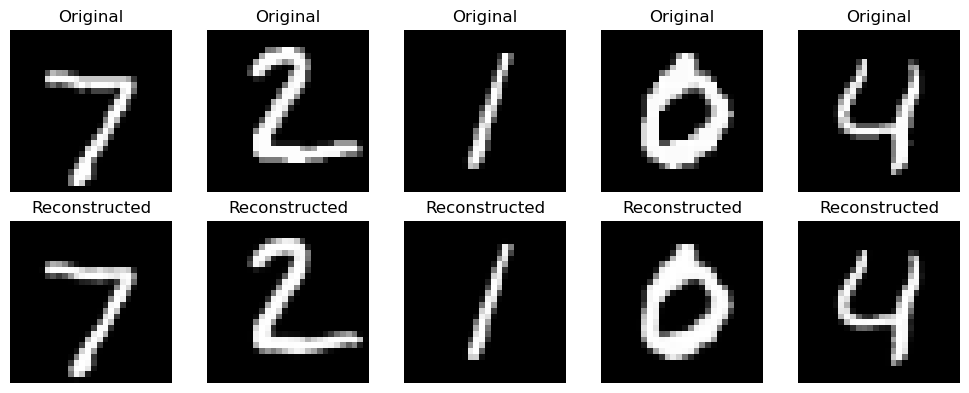

In [13]:
plt.figure(figsize=(10, 4))

for i in range(5):

    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstructed image
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()

In [ ]:
1) Buil-in dataset , first 5 rows display

In [ ]:
2) Encoder 

In [ ]:
3) LSTM Architecture

In [ ]:
4) Compile - Model